In [144]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
from GB84_eqs import f as flux, rho_m
from updraft_emmanuel import w_parcel 
import new_rainfall_scheme as nr
import top_outflow as outflow

## Loading the data

In [145]:
#time to check
slice_str = "2024-07-16T00:00:00, 2024-07-16T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


In [146]:
data_era = xr.open_mfdataset(r'..\data\ERA5\profiles\*.nc')
time_dim = 'valid_time'
data_era_10min = data_era.resample({time_dim: '10min'}).interpolate('linear')
data_surface = xr.open_dataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')


In [147]:
data_era = data_era_10min.sel(valid_time=slice(*slice_tuple))
data_era = data_era.sel(latitude=51.96,longitude=4.9,method='nearest')
data_era = data_era.sortby('pressure_level', ascending=False)
data_era = data_era.sel(pressure_level=slice(1e5,200))
time = data_era_10min.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)
data_surface = data_surface.sel(time=time, method='nearest')

In [148]:
data_era.t

<xarray.DataArray 't' (valid_time: 144, pressure_level: 23)> Size: 13kB
dask.array<getitem, shape=(144, 23), dtype=float32, chunksize=(144, 23), chunktype=numpy.ndarray>
Coordinates:
  * pressure_level  (pressure_level) float64 184B 1e+03 975.0 ... 225.0 200.0
    latitude        float64 8B 52.0
    longitude       float64 8B 5.0
    number          int64 8B 0
  * valid_time      (valid_time) datetime64[ns] 1kB 2024-07-16 ... 2024-07-16...
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      357
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    K
    standard_name:                            air_temperature

In [149]:
my_temp = data_era.t.values
p = data_era.pressure_level*100
q_v = data_era.q.values
Z = data_era.z.values/g

In [150]:
my_temp_surface = data_surface.TA002.values
p_surface = data_surface.P0.values*100
T_d = data_surface.TD002.values
Z_surface = 2*np.ones(len(p_surface))  

In [151]:
def relative_humidity(t_air, t_dew):
    """
    t_air and t_dew in Celsius
    Returns RH in %
    """
    rh = 100 * (np.exp((17.67 * t_dew) / (t_dew + 243.5)) / 
                np.exp((17.67 * t_air) / (t_air + 243.5)))
    return rh

In [152]:
T_air = np.concatenate([my_temp_surface.reshape(len(my_temp_surface), 1), my_temp], 1)
p_surf = p_surface #[Pa]
p_air = np.tile(p.values,(len(p_surf),1))
p_air = np.concatenate([p_surf.reshape(len(p_surf), 1), p_air], 1) #[Pa]
Z = np.concatenate([Z_surface.reshape(len(Z_surface), 1), Z], 1)

RH_surf = relative_humidity(my_temp_surface, T_d)
q_v_surf = specific_humidity_from_rh(my_temp_surface,RH_surf/100, p_surf)
q_v_air = np.concatenate([q_v_surf.reshape(len(q_v_surf), 1), q_v], 1) 

#### Environmental profiles and inputs

T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values

#### Parsivel rainfall data

In [153]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


## Running the model

### Parcel Profiles

In [154]:
rows = T_air.shape[0]
cols = T_air.shape[1]

In [155]:
T_arr = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
my_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


In [156]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

theta_type = 'theta_e_reversible'       #choose which approach to follow for the conserved potential temperature

for i in range(0,T_air.shape[0]):
    print(i)
    #calculating the profiles
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.Temp_prof(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], my_temp_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.T_v(T_d[i],p_new[i,0],p_new[i],temp_parcel[i,:],int(lcl_index[i]),theta_type=theta_type)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143


In [157]:
T_v_env = my_temp_new*(1+0.61*q_v_new)

### Cloud Heights

In [158]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

In [159]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.cloud_top(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel[i])

### Updraft speed

In [160]:
import updraft_emmanuel

w_parcel_max = np.zeros(rows)

for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)
    #print(top_index,int(LFC_index[i,1]))
    w_parcel_max[i],CAPE = updraft_emmanuel.w_parcel(p_new[i],T_v_moist[i],T_v_env[i],LFC_index[i,1],p_t[i],top_index)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143


### State calculation and update

In [ ]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)

    w_avg = w_parcel_max[i]/2
    rho = rho_m(T_s[i],my_temp_new[i,min(top_index,cols-1)],p_s[i],p_t[i])

    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = flux(T_d[i],p_new[i,0],p_t[i],my_temp_new[i,min(top_index,cols-1)],rho,w_avg)

    if i<rows-1:
        if X[i]/Z_c[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            X[i] = 2.5e-3*Z_c[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.autoconoversion_rate(X[i],Z_c[i],thresh)*dt_seconds[i] - outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        print(outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i])
        X[i+1] = max(0,X[i+1])

0
0.0
1
0.0
2
0.0
3
0.0
4
0.0
5
0.0
6
0.0
7
0.0
8
0.0
9
0.0
10
0.0
11
0.0
12
0.0
13
0.0
14
0.0
15
0.0
16
0.0
17
0.0
18
0.0
19
0.0
20
0.0
21
0.0
22
0.0
23
0.0
24
0.0
25
0.0
26
0.0
27
0.0
28
0.0
29
0.0
30
0.0
31
0.0
32
0.0
33
0.0
34
0.0
35
0.0
36
0.0
37
0.0
38
0.0
39
0.0
40
0.0
41
0.0
42
0.0
43
0.5291315921767819
44
0.0
45
1.2069042468573
46
0.0
47
0.0
48
23.60845269185713
49
10.218255791914656
50
22.423026907776126
51
0.0
52
0.2187872695664513
53
43.93625796153073
54
31.8402368203273
55
23.35187310370852
56
38.63122852615238
57
36.79745231169033
58
34.167881724646485
59
39.728551409394576
60
0.0
61
0.0
62
0.0
63
0.0
64
0.07771857763981531
65
66.37127391456836
66
60.67840940040506
67
0.0
68
0.0
69
29.153832248921333
70
0.0
71
0.0
72
0.0024218224845490182
73
0.0
74
0.0
75
0.0
76
0.0
77
0.0
78
0.9052547371857184
79
0.0
80
58.33289683100024
81
59.487774427494685
82
69.96853166347414
83
63.38978968473187
84
60.41101243549713
85
30.732698142923145
86
49.69742619506683
87
31.943720875310934
88

#### Rainfall rates

In [162]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    R[i] = ar.autoconoversion_rate(X[i],Z_c[i],thresh)
    if R[i]<=1e-6:
        P[i] = 0
    else:
        print(i)
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(my_temp_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c[i],w_parcel_max[i]/2*100).calculate_D_c()
        P[i] = nr.precipitation_rate(ar.autoconoversion_rate(X[i],Z_c[i],thresh), mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

42
15.084958214222482 186.2513486955189
43
12.938646086024352 154.13897773387995
46
1.191679858087095 26.913199570188475
47
0.7922654720544642 23.386425873682644
48
0.2421559996622189 18.585518892521886
49
2.077105062441527 34.860201538774646
50
0.368919238415929 19.68611838018564
51
14.310817272882431 174.08806025022332
53
-0.7329232514534758 10.229340932333981
54
-0.2909405753598442 13.993318197086067
55
-0.11018216864966268 15.543906995033621
56
-0.6443213253987858 10.980800930360827
57
-0.5994189250349762 11.362218265380438
58
-0.4776426378432346 12.398627505353732
59
-0.9187890901961056 8.657909423728038
60
-0.9100335156540122 8.731785126000416
61
14.574426796528922 178.14719090697884
62
15.397109121475332 191.37873166339293
63
13.712322536946862 165.1580515882568
65
-1.1452883174135984 6.751902662125411
66
-1.0913938277149082 7.204542804691112
67
-0.8508879148912905 9.231216339030393
68
-0.8566255943653496 9.182737278337388
69
-0.25689492002649805 14.284866151081555
70
18.0073839

## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

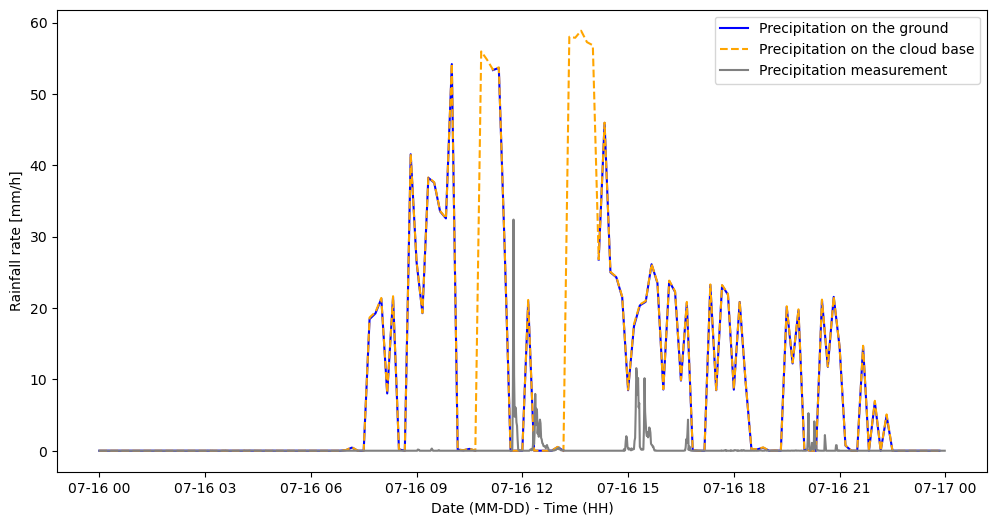

In [163]:
plt.figure(figsize=(12,6))
plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(time,R*3600,color='orange',linestyle='--',label='Precipitation on the cloud base')
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')
plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

#### Virtual Temperature profiles at different times

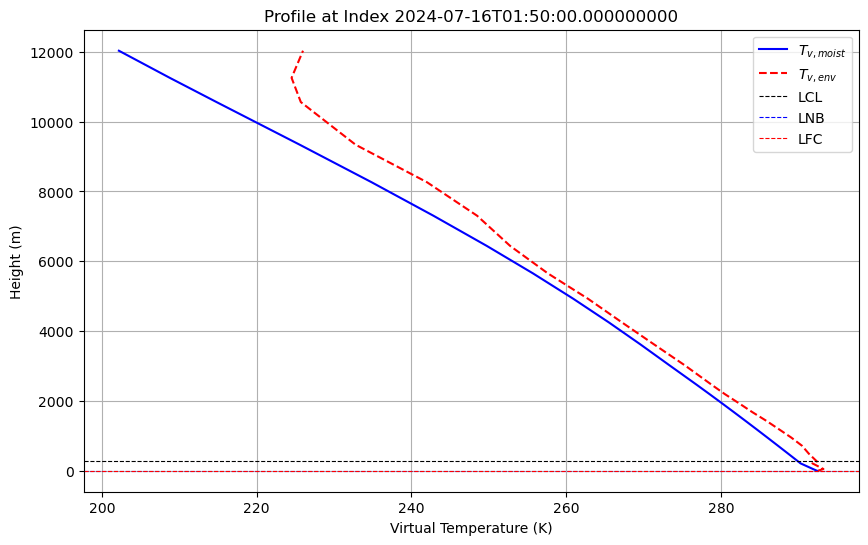

In [164]:
index_2 = 11
fig,ax2 = plt.subplots(figsize=(10,6))
ax2.plot(T_v_moist[index_2], Z_new[index_2], label='$T_{v,moist}$', color='blue')
ax2.plot(my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.axhline(y=Z[index_2,int(lcl_index[index_2])], color='black', linestyle='--',linewidth='0.8',label='LCL')
ax2.axhline(y=Z_t[index_2], color='blue', linestyle='--',linewidth='0.8',label='LNB')
ax2.axhline(y=Z[index_2,int(LFC_index[index_2,1])], color='red', linestyle='--',linewidth='0.8',label='LFC')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

#### Cloud top and base

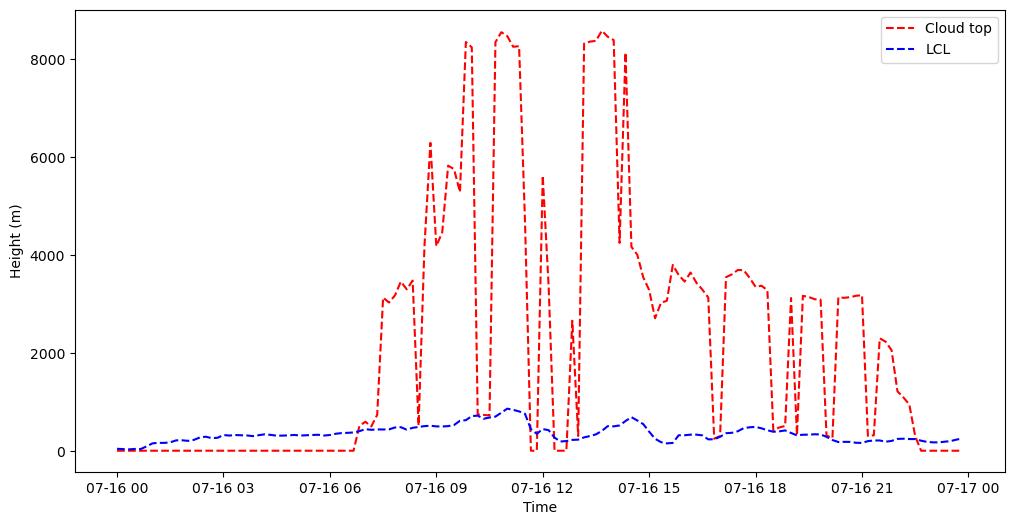

In [165]:
plt.figure(figsize=(12,6))
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Time')
plt.legend()

#### Updraft velocity

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

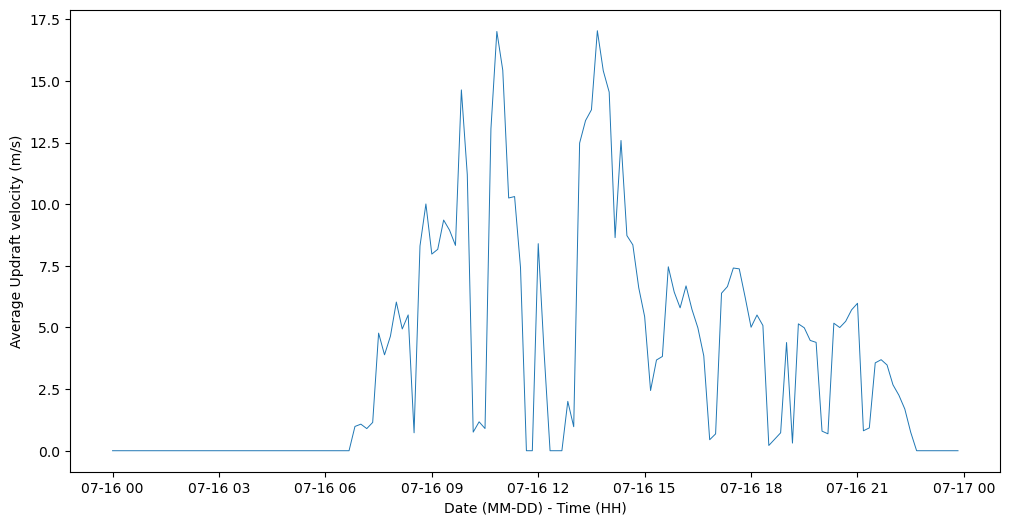

In [166]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

#### LWC and LWP(state)

(0.0, 10.0)

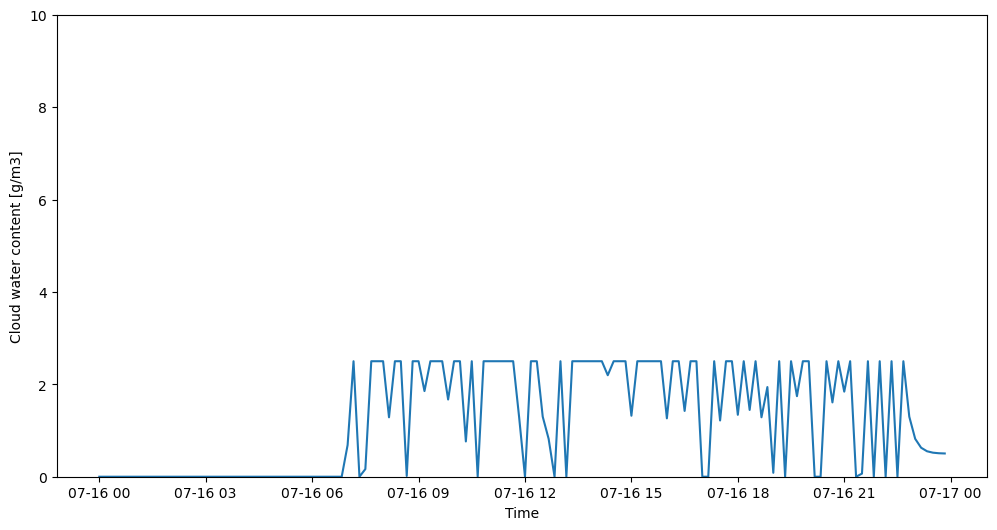

In [167]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

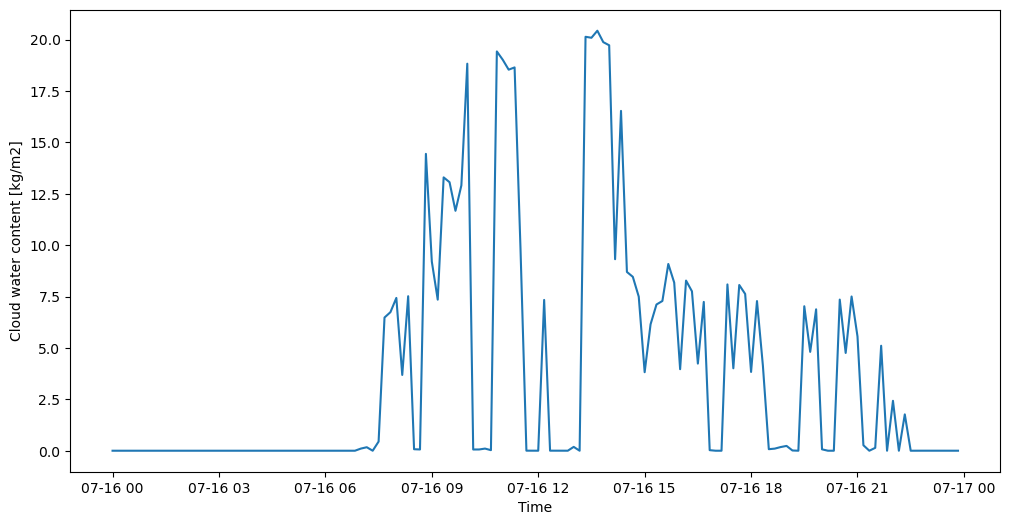

In [168]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

#### Size distribution

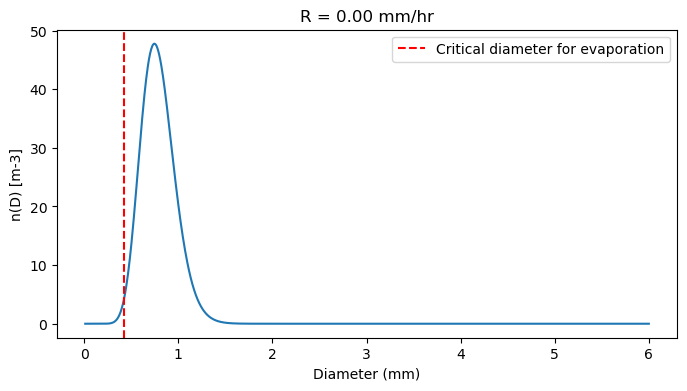

In [169]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()